# 🏦 Prediksi Kelayakan Kredit Nasabah
## Menggunakan Random Forest & K-Means Clustering dengan Explainable AI (SHAP)

---
**Framework:** CRISP-DM (Cross Industry Standard Process for Data Mining)

**Metode:**
- Classification: Random Forest
- Clustering: K-Means
- Explainability: SHAP (SHapley Additive exPlanations)

**Dataset:** Credit Risk Dataset (32.581 records, 12 fitur)

---

## Instalasi & Import Library

In [1]:
# Install library
!pip install shap imbalanced-learn -q

In [2]:
#Data Manipulation
import pandas as pd
import numpy as np

#Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE

#Modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, silhouette_score,
    roc_auc_score, roc_curve
)

#Explainability
import shap

#Simpan Model
import joblib

import warnings
warnings.filterwarnings('ignore')

# Styling plot
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.dpi'] = 100

print(' Semua library berhasil diimport')

 Semua library berhasil diimport


---
## 📌 FASE 1 — Business Understanding (CRISP-DM)

### Latar Belakang
Lembaga keuangan dan perbankan menghadapi risiko kredit berupa kemungkinan nasabah gagal memenuhi kewajiban pembayaran (default). Proses penilaian kelayakan kredit secara manual bersifat subjektif dan memakan waktu. Pendekatan Data Mining dapat mengotomasi dan meningkatkan akurasi penilaian ini.

### Tujuan
1. Membangun model klasifikasi untuk memprediksi apakah nasabah akan **gagal bayar (1)** atau **tidak (0)**.
2. Mengelompokkan nasabah ke dalam segmen risiko menggunakan clustering.
3. Menjelaskan faktor-faktor yang memengaruhi prediksi menggunakan SHAP.

### Pertanyaan Bisnis
- Fitur apa yang paling menentukan kelayakan kredit seorang nasabah?
- Bagaimana profil nasabah berisiko tinggi vs rendah?
- Seberapa andal model dalam mengidentifikasi nasabah yang akan gagal bayar?

---
## 📂 FASE 2 — Data Understanding

In [3]:
#Load Dataset Kaggle

!pip install kagglehub[pandas-datasets] -q

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "laotse/credit-risk-dataset",
    "credit_risk_dataset.csv"
)

print(f' Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
df.head()

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
 Dataset berhasil dimuat!
Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
#Informasi Tipe Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
#Statistik Deskriptif
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [6]:
#Cek Missing Value
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

                   Jumlah Missing  Persentase (%)
person_emp_length             895            2.75
loan_int_rate                3116            9.56


### 📊 Exploratory Data Analysis (EDA)

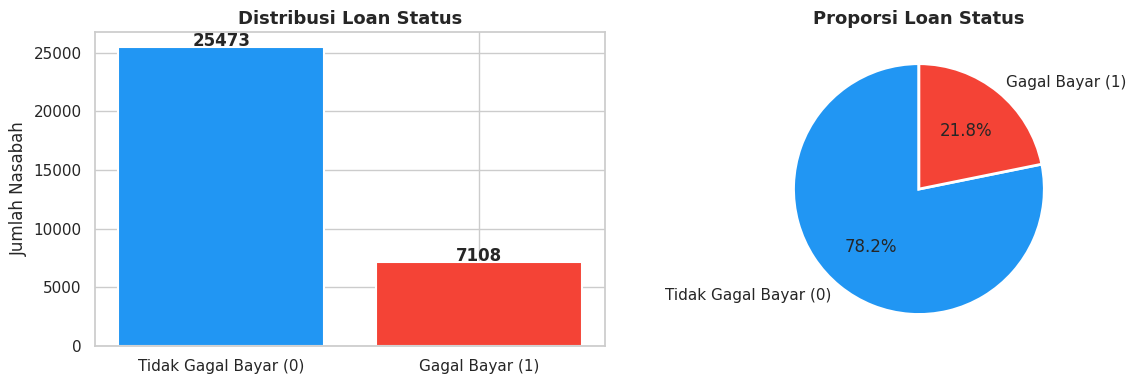


Kelas 0 (Tidak Gagal): 25,473 (78.2%)
Kelas 1 (Gagal Bayar): 7,108 (21.8%)
 Dataset tidak seimbang (imbalanced) akan ditangani dengan SMOTE


In [7]:
#1. Distribusi Target (Loan Status)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['loan_status'].value_counts()
labels = ['Tidak Gagal Bayar (0)', 'Gagal Bayar (1)']
colors = ['#2196F3', '#F44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Loan Status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('dist_loan_status.png', bbox_inches='tight')
plt.show()
print(f'\nKelas 0 (Tidak Gagal): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Kelas 1 (Gagal Bayar): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(' Dataset tidak seimbang (imbalanced) akan ditangani dengan SMOTE')

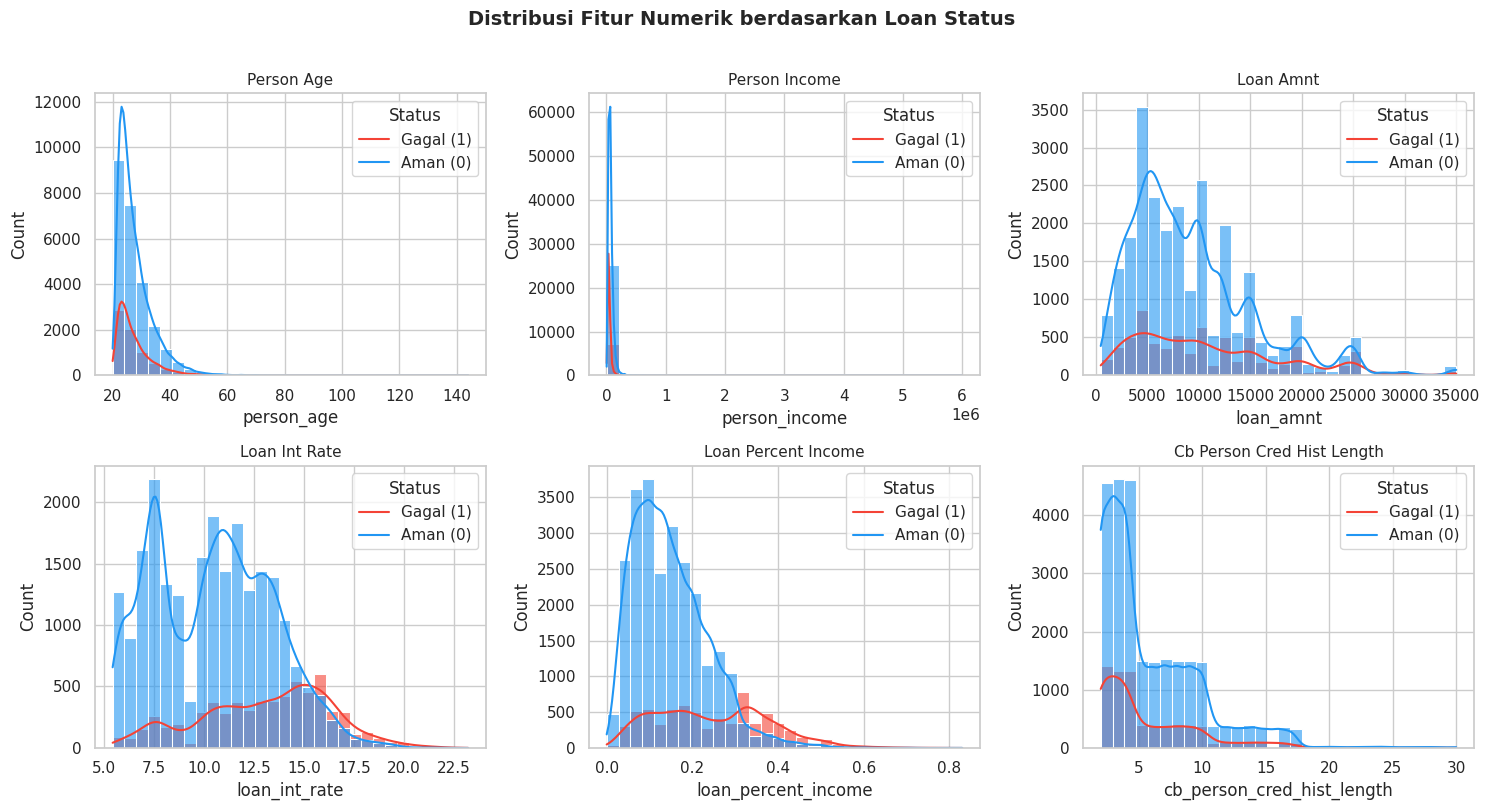

In [8]:
#2. Distribusi Fitur Numerik
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
            'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='loan_status', bins=30,
                 palette={0: '#2196F3', 1: '#F44336'},
                 ax=axes[i], kde=True, alpha=0.6)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].legend(title='Status', labels=['Gagal (1)', 'Aman (0)'])

plt.suptitle('Distribusi Fitur Numerik berdasarkan Loan Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dist_numerik.png', bbox_inches='tight')
plt.show()

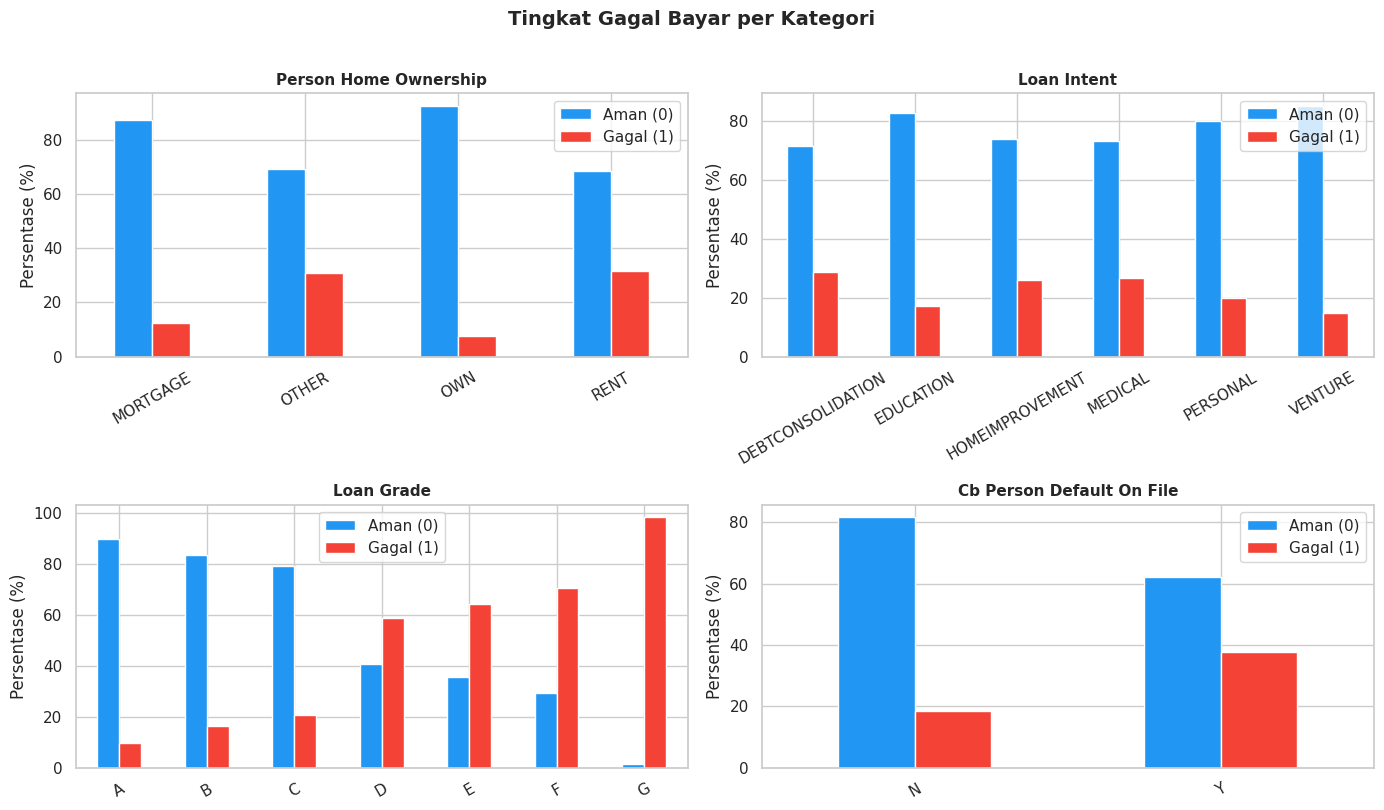

In [9]:
#3. Distribusi Fitur Kategorikal ───────────────────────
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.columns = ['Aman (0)', 'Gagal (1)']
    ct.plot(kind='bar', ax=axes[i], color=['#2196F3', '#F44336'],
            edgecolor='white', rot=30)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('Tingkat Gagal Bayar per Kategori', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dist_kategorikal.png', bbox_inches='tight')
plt.show()

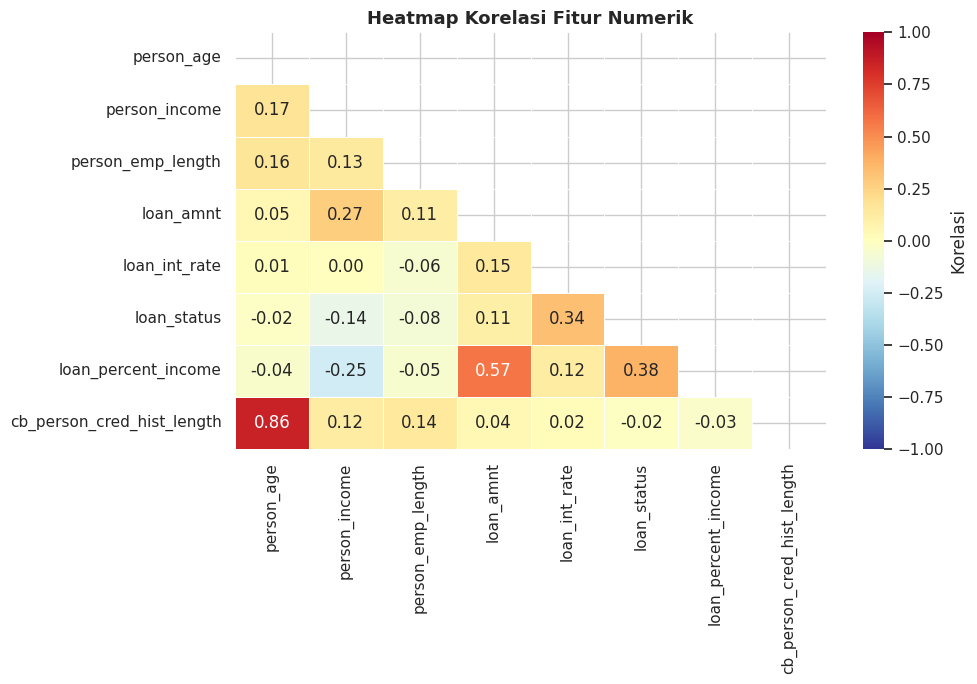

In [10]:
#4. Heatmap Korelasi
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Korelasi'})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

---
## 🔧 FASE 3 — Data Preprocessing

In [11]:
#Salin Dataset
df_clean = df.copy()
print(f'Ukuran awal: {df_clean.shape}')

Ukuran awal: (32581, 12)


In [12]:
#1. Imputasi Missing Value
# Menggunakan median agar tidak membuang data (lebih baik dari dropna)
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

print('Missing value setelah imputasi:')
print(df_clean.isnull().sum())

Missing value setelah imputasi:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [13]:
#2. Penanganan Outlier
print('Sebelum hapus outlier:', df_clean.shape)

# person_age > 80 tidak realistis (max = 144 → data error)
df_clean = df_clean[df_clean['person_age'] <= 80]

# person_emp_length > 60 tidak realistis
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

print('Setelah hapus outlier:', df_clean.shape)
print(f'Data dihapus: {len(df) - len(df_clean)} baris')

Sebelum hapus outlier: (32581, 12)
Setelah hapus outlier: (32572, 12)
Data dihapus: 9 baris


In [14]:
#3. Encoding Fitur Kategorikal
# Simpan encoder per kolom untuk digunakan di aplikasi Streamlit
categorical_columns = df_clean.select_dtypes(include='object').columns.tolist()
print('Kolom kategorikal:', categorical_columns)

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le
    print(f'  {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}')

# Simpan encoders
joblib.dump(encoders, 'encoders.pkl')
print('\n Encoders disimpan ke encoders.pkl')

Kolom kategorikal: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
  person_home_ownership: ['MORTGAGE', 'OTHER', 'OWN', 'RENT'] → [0, 1, 2, 3]
  loan_intent: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE'] → [0, 1, 2, 3, 4, 5]
  loan_grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G'] → [0, 1, 2, 3, 4, 5, 6]
  cb_person_default_on_file: ['N', 'Y'] → [0, 1]

 Encoders disimpan ke encoders.pkl


In [15]:
#4. Pisahkan Fitur dan Target
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

feature_names = X.columns.tolist()
print('Fitur input:', feature_names)
print('Jumlah fitur:', len(feature_names))
print('\nDistribusi target:')
print(y.value_counts())

Fitur input: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
Jumlah fitur: 11

Distribusi target:
loan_status
0    25465
1     7107
Name: count, dtype: int64


In [16]:
#5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts()}')

Train set: (26057, 11) | Test set: (6515, 11)

Distribusi y_train:
loan_status
0    20372
1     5685
Name: count, dtype: int64

Distribusi y_test:
loan_status
0    5093
1    1422
Name: count, dtype: int64


Distribusi setelah SMOTE:
loan_status
0    20372
1    20372
Name: count, dtype: int64


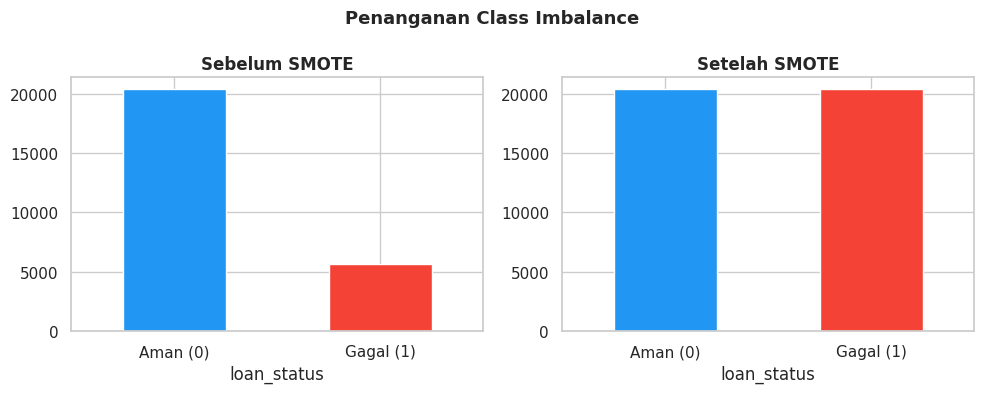

In [17]:
#6. Penanganan Class Imbalance dengan SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribusi setelah SMOTE:')
print(pd.Series(y_train_sm).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2196F3', '#F44336']
y_train.value_counts().plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Sebelum SMOTE', fontweight='bold')
axes[0].set_xticklabels(['Aman (0)', 'Gagal (1)'])

pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=colors, rot=0)
axes[1].set_title('Setelah SMOTE', fontweight='bold')
axes[1].set_xticklabels(['Aman (0)', 'Gagal (1)'])

plt.suptitle('Penanganan Class Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', bbox_inches='tight')
plt.show()

---
## 🌲 FASE 4A — Klasifikasi: Random Forest

In [18]:
#Training Model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',   # fallback jika tidak memakai SMOTE
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, y_train_sm)
print(' Model Random Forest selesai ditraining')

 Model Random Forest selesai ditraining


In [19]:
#Prediksi
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [20]:
#Evaluasi Lengkap
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('       HASIL EVALUASI RANDOM FOREST')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Tidak Gagal (0)', 'Gagal Bayar (1)']))

       HASIL EVALUASI RANDOM FOREST
  Accuracy  : 0.8927  (89.27%)
  Precision : 0.7641
  Recall    : 0.7356
  F1-Score  : 0.7496
  ROC-AUC   : 0.9141

Classification Report:
                 precision    recall  f1-score   support

Tidak Gagal (0)       0.93      0.94      0.93      5093
Gagal Bayar (1)       0.76      0.74      0.75      1422

       accuracy                           0.89      6515
      macro avg       0.85      0.84      0.84      6515
   weighted avg       0.89      0.89      0.89      6515



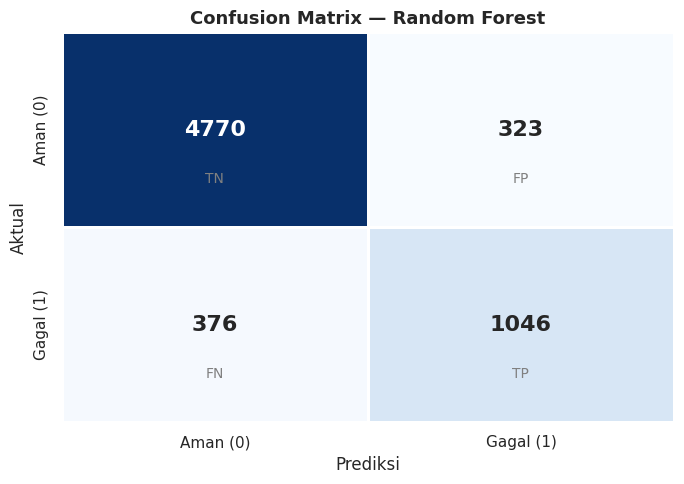

In [21]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Aman (0)', 'Gagal (1)'],
            yticklabels=['Aman (0)', 'Gagal (1)'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 16, 'fontweight': 'bold'})

plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)

# Tambah label TP, TN, FP, FN
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.75, labels[i][j],
                 ha='center', va='center', fontsize=10,
                 color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

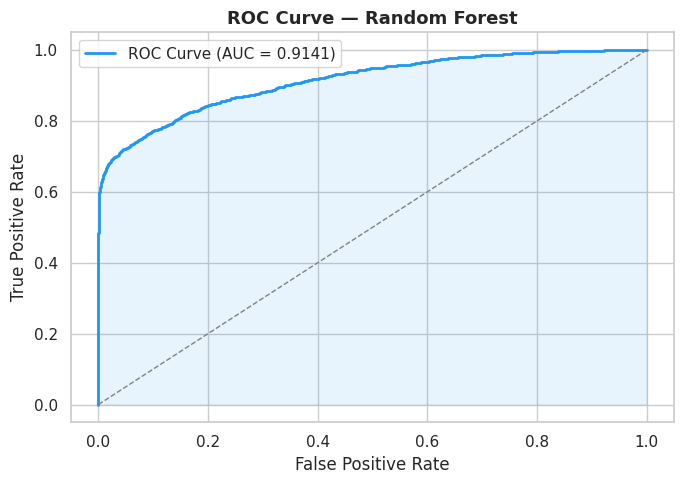

In [22]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2196F3', lw=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

In [23]:
#Cross Validation
cv_scores = cross_val_score(rf_model, X_train_sm, y_train_sm,
                            cv=5, scoring='f1', n_jobs=-1)

print('Cross Validation (5-Fold) — F1 Score:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross Validation (5-Fold) — F1 Score:
  Fold 1: 0.8364
  Fold 2: 0.8831
  Fold 3: 0.9073
  Fold 4: 0.9112
  Fold 5: 0.9140
  Mean  : 0.8904 ± 0.0292


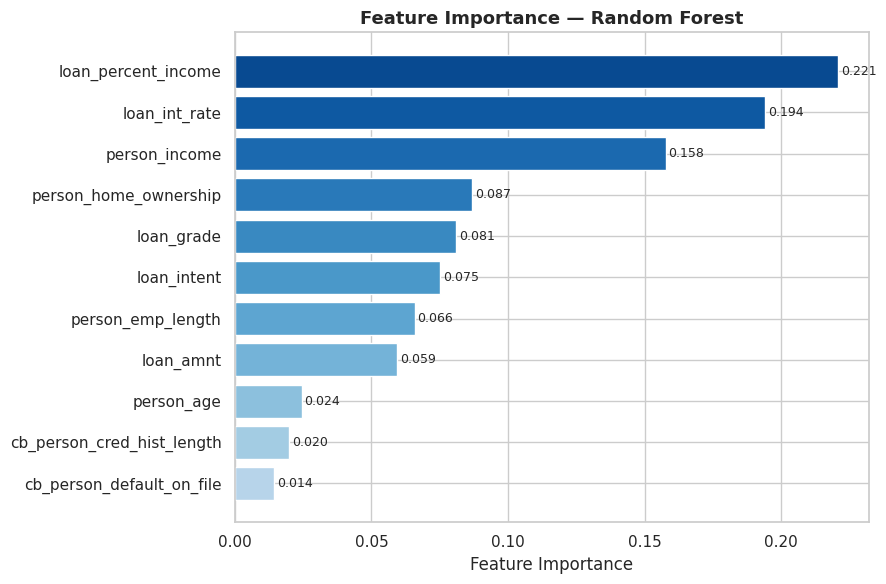

In [24]:
#Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color=plt.cm.Blues(np.linspace(0.3, 0.9, len(importance_df))))

for bar, val in zip(bars, importance_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

---
## 🔵 FASE 4B — Clustering: K-Means

In [25]:
#Normalisasi Data untuk Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simpan scaler
joblib.dump(scaler, 'scaler.pkl')
print(' Scaler disimpan ke scaler.pkl')

 Scaler disimpan ke scaler.pkl


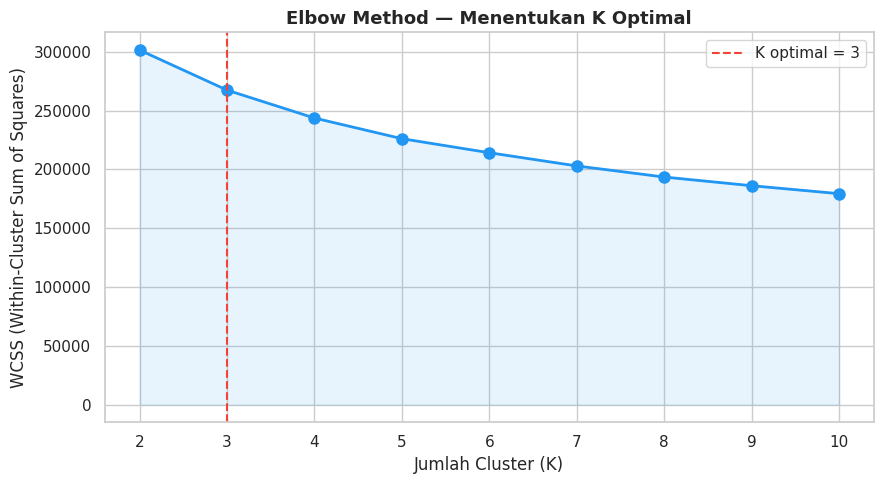

In [26]:
#Elbow Method
wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, marker='o', color='#2196F3', linewidth=2, markersize=8)
plt.fill_between(K_range, wcss, alpha=0.1, color='#2196F3')
plt.axvline(x=3, color='#F44336', linestyle='--', linewidth=1.5,
            label='K optimal = 3')
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Menentukan K Optimal', fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_method.png', bbox_inches='tight')
plt.show()

In [27]:
#Training K-Means dengan K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Menambahkan label cluster ke dataframe
df_clustered = df_clean.copy()
df_clustered['Cluster'] = clusters

# Evaluasi
sil_score = silhouette_score(X_scaled, clusters)
print(f' K-Means selesai — K = 3')
print(f'Silhouette Score: {sil_score:.4f}')
print('(Skor 0.5–0.7 = struktur cluster baik; >0.7 = sangat baik)')
print()
print('Distribusi anggota per cluster:')
print(pd.Series(clusters).value_counts().sort_index().rename(index={0:'Cluster 0', 1:'Cluster 1', 2:'Cluster 2'}))

 K-Means selesai — K = 3
Silhouette Score: 0.1970
(Skor 0.5–0.7 = struktur cluster baik; >0.7 = sangat baik)

Distribusi anggota per cluster:
Cluster 0     7984
Cluster 1     5725
Cluster 2    18863
Name: count, dtype: int64


PCA: PC1 menjelaskan 21.8%, PC2 menjelaskan 18.7%
Total variasi terjelaskan: 40.5%


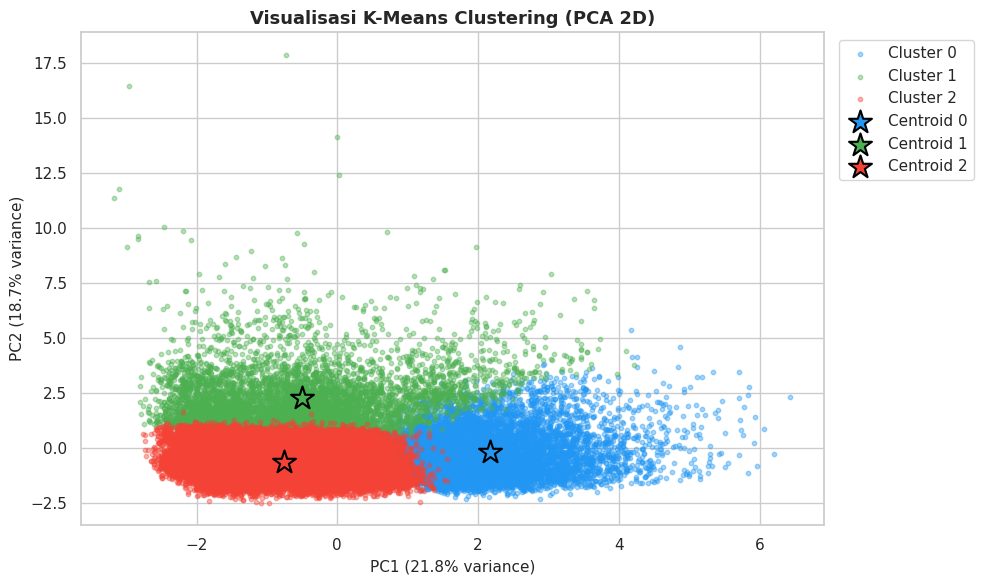

In [28]:
#Visualisasi Cluster dengan PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f'PCA: PC1 menjelaskan {explained[0]:.1f}%, PC2 menjelaskan {explained[1]:.1f}%')
print(f'Total variasi terjelaskan: {sum(explained):.1f}%')

colors_cluster = ['#2196F3', '#4CAF50', '#F44336']
labels_cluster = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(10, 6))
for i in range(3):
    mask = clusters == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_cluster[i], label=labels_cluster[i],
                alpha=0.4, s=10)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, c in enumerate(centroids_pca):
    plt.scatter(c[0], c[1], marker='*', s=300,
                c=colors_cluster[i], edgecolors='black', linewidths=1.5,
                label=f'Centroid {i}', zorder=5)

plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.title('Visualisasi K-Means Clustering (PCA 2D)', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('cluster_pca.png', bbox_inches='tight')
plt.show()

In [29]:
#Profil / Karakteristik Setiap Cluster
# Decode kolom kategorikal untuk analisis yang mudah dibaca
df_profile = df_clustered.copy()
for col, le in encoders.items():
    df_profile[col] = le.inverse_transform(df_profile[col])

print('=== PROFIL CLUSTER (Rata-rata Fitur Numerik) ===')
num_profile = df_profile.groupby('Cluster')[[
    'person_age', 'person_income', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'loan_status'
]].mean().round(2)
num_profile.columns = ['Usia', 'Pendapatan', 'Jumlah Pinjaman',
                       'Suku Bunga (%)', 'Rasio Pinjaman', 'Proporsi Gagal Bayar']
print(num_profile)

print('\n=== DISTRIBUSI LOAN STATUS PER CLUSTER ===')
ct = pd.crosstab(df_clustered['Cluster'], df_clustered['loan_status'])
ct.columns = ['Aman (0)', 'Gagal (1)']
ct['Total'] = ct.sum(axis=1)
ct['% Gagal'] = (ct['Gagal (1)'] / ct['Total'] * 100).round(1)
print(ct)

=== PROFIL CLUSTER (Rata-rata Fitur Numerik) ===
          Usia  Pendapatan  Jumlah Pinjaman  Suku Bunga (%)  Rasio Pinjaman  \
Cluster                                                                       
0        26.66    61941.21         10704.78           14.63            0.19   
1        36.91    91412.66         10989.97           10.42            0.15   
2        25.37    59795.94          8689.98            9.66            0.17   

         Proporsi Gagal Bayar  
Cluster                        
0                        0.45  
1                        0.13  
2                        0.15  

=== DISTRIBUSI LOAN STATUS PER CLUSTER ===
         Aman (0)  Gagal (1)  Total  % Gagal
Cluster                                     
0            4399       3585   7984     44.9
1            4960        765   5725     13.4
2           16106       2757  18863     14.6


Pemetaan Cluster → Label Risiko:
  Cluster 1 → Risiko Rendah (gagal bayar: 13.4%)
  Cluster 2 → Risiko Sedang (gagal bayar: 14.6%)
  Cluster 0 → Risiko Tinggi (gagal bayar: 44.9%)


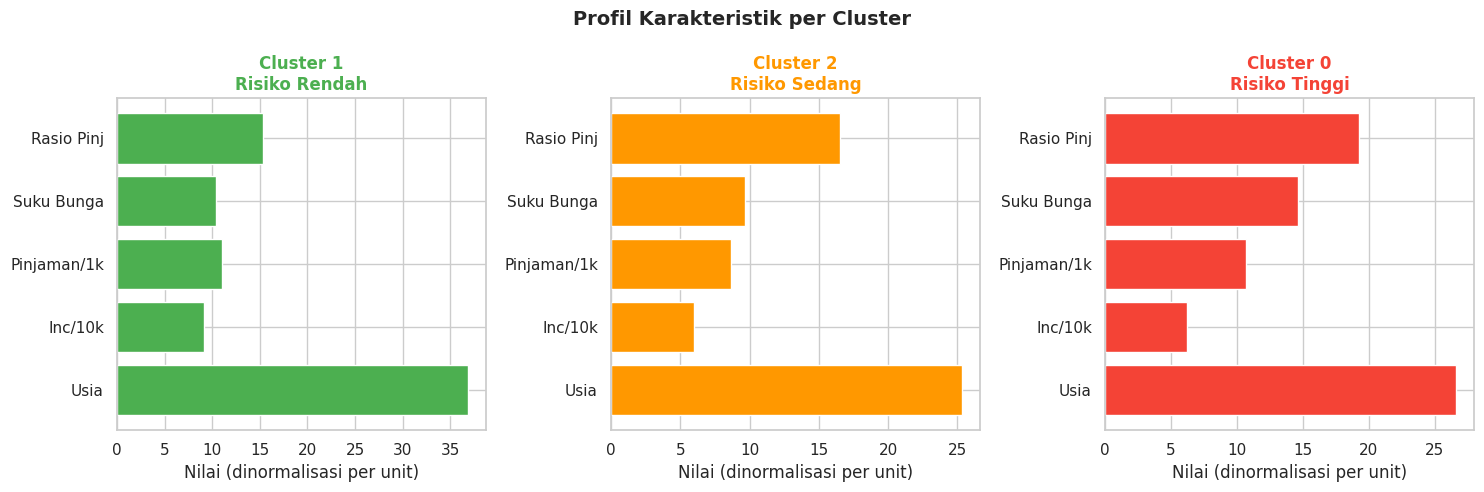

In [30]:
#Interpretasi & Labeling Cluster
# Berdasarkan proporsi gagal bayar:
#   Cluster dengan % gagal terkecil → Risiko Rendah
#   Cluster dengan % gagal terbesar → Risiko Tinggi
#   Cluster tengah                  → Risiko Sedang

gagal_per_cluster = df_clustered.groupby('Cluster')['loan_status'].mean()
sorted_clusters = gagal_per_cluster.sort_values().index.tolist()

cluster_labels = {}
risk_levels = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
for i, c in enumerate(sorted_clusters):
    cluster_labels[c] = risk_levels[i]

df_clustered['Risk_Label'] = df_clustered['Cluster'].map(cluster_labels)

print('Pemetaan Cluster → Label Risiko:')
for c, label in cluster_labels.items():
    pct = gagal_per_cluster[c] * 100
    print(f'  Cluster {c} → {label} (gagal bayar: {pct:.1f}%)')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
risk_colors = {'Risiko Rendah': '#4CAF50', 'Risiko Sedang': '#FF9800', 'Risiko Tinggi': '#F44336'}

for i, (c, label) in enumerate(cluster_labels.items()):
    subset = df_profile[df_clustered['Cluster'] == c]
    axes[i].barh(
        ['Usia', 'Inc/10k', 'Pinjaman/1k', 'Suku Bunga', 'Rasio Pinj'],
        [subset['person_age'].mean(),
         subset['person_income'].mean()/10000,
         subset['loan_amnt'].mean()/1000,
         subset['loan_int_rate'].mean(),
         subset['loan_percent_income'].mean()*100],
        color=risk_colors[label], edgecolor='white'
    )
    axes[i].set_title(f'Cluster {c}\n{label}',
                      fontsize=12, fontweight='bold',
                      color=risk_colors[label])
    axes[i].set_xlabel('Nilai (dinormalisasi per unit)')

plt.suptitle('Profil Karakteristik per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profil.png', bbox_inches='tight')
plt.show()

---
## 💡 FASE 5 — Explainable AI (SHAP)

In [31]:
#Inisialisasi SHAP Explainer
#Menggunakan 500 sample dari test set agar lebih cepat
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# TreeExplainer menghasilkan list [kelas_0, kelas_1]
# Ambil SHAP values untuk kelas 1 (gagal bayar)
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
else:
    sv_class1 = shap_values[:, :, 1]

print(f'SHAP values shape: {np.array(sv_class1).shape}')
print(' SHAP explainer siap')

SHAP values shape: (500, 11)
 SHAP explainer siap


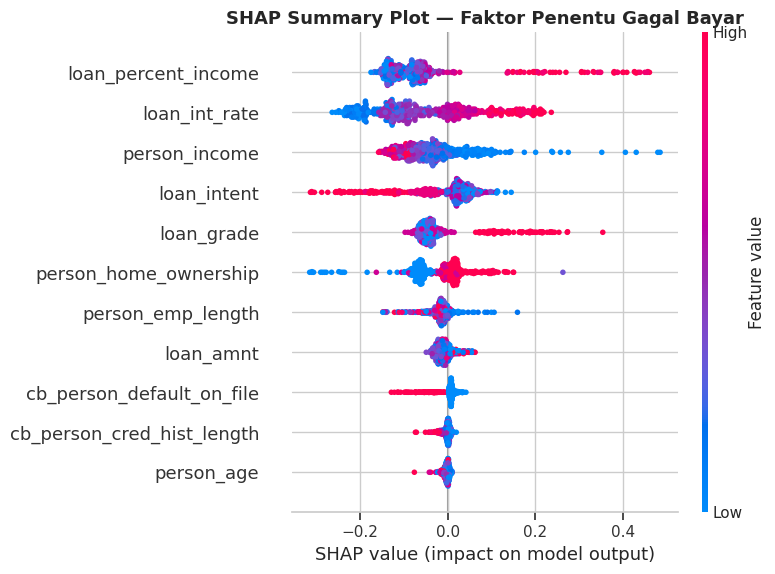

In [32]:
#SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_class1, X_sample,
                  feature_names=feature_names,
                  show=False, max_display=11)
plt.title('SHAP Summary Plot — Faktor Penentu Gagal Bayar',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

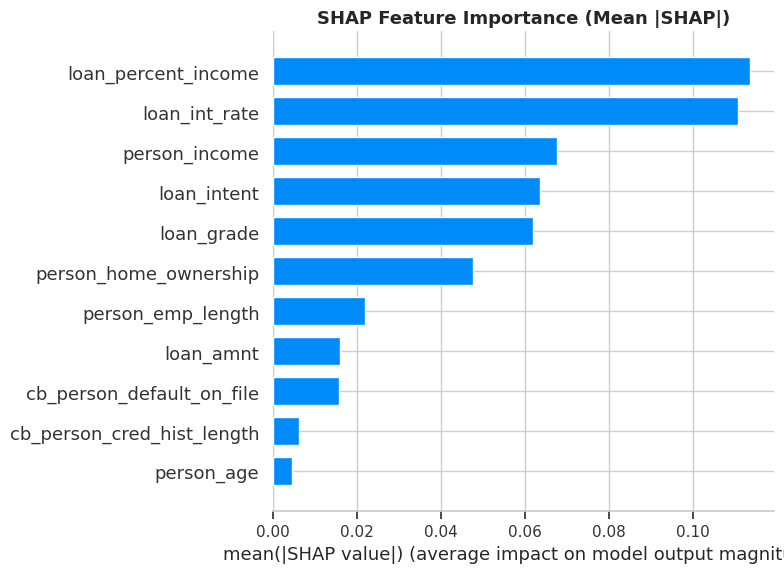

In [33]:
#SHAP Bar Plot (Mean Absolute)
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_class1, X_sample,
                  feature_names=feature_names,
                  plot_type='bar', show=False, max_display=11)
plt.title('SHAP Feature Importance (Mean |SHAP|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

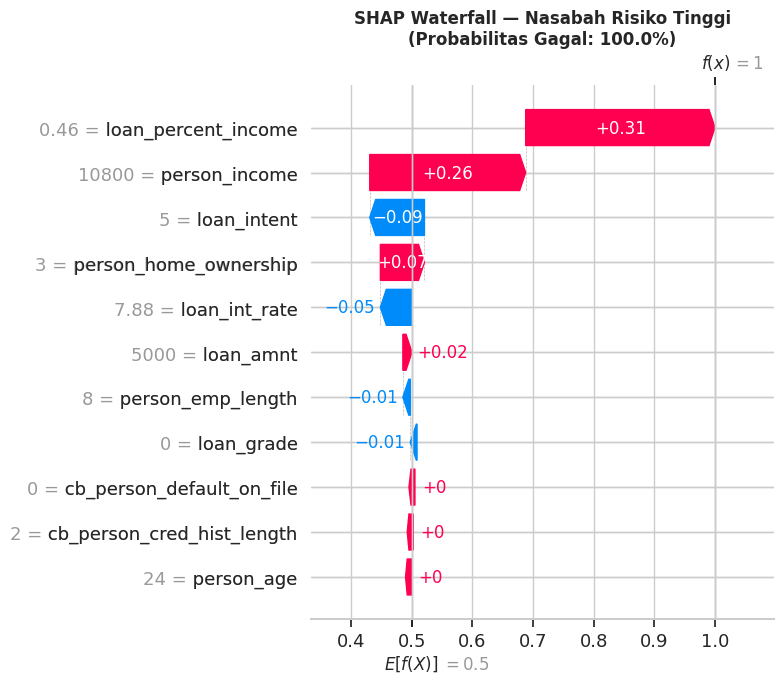

In [34]:
#SHAP Waterfall Plot (1 Contoh Prediksi)
# Ambil 1 sampel yang diprediksi GAGAL BAYAR dengan probabilitas tinggi
proba_sample = rf_model.predict_proba(X_sample)[:, 1]
idx_high_risk = np.argmax(proba_sample)  # nasabah dengan risiko tertinggi

explanation = explainer(X_sample.iloc[[idx_high_risk]])
if isinstance(explanation.values, np.ndarray) and explanation.values.ndim == 3:
    # Versi SHAP baru: shape (1, n_features, n_classes)
    exp_single = shap.Explanation(
        values=explanation.values[0, :, 1],
        base_values=explanation.base_values[0][1],
        data=explanation.data[0],
        feature_names=feature_names
    )
else:
    exp_single = explanation[0]

plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp_single, show=False, max_display=11)
plt.title(f'SHAP Waterfall — Nasabah Risiko Tinggi\n(Probabilitas Gagal: {proba_sample[idx_high_risk]*100:.1f}%)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()

---
## 📊 FASE 6 — Ringkasan & Perbandingan Hasil

In [35]:
#Tabel Ringkasan Evaluasi
summary = pd.DataFrame({
    'Metrik'  : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Silhouette Score'],
    'Nilai'   : [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}',
                 f'{f1:.4f}', f'{auc:.4f}', f'{sil_score:.4f}'],
    'Metode'  : ['Random Forest']*5 + ['K-Means'],
    'Keterangan': [
        'Persentase prediksi benar',
        'Presisi prediksi gagal bayar',
        'Sensitivitas mendeteksi gagal bayar',
        'Harmonik mean precision & recall',
        'Kemampuan diskriminasi model',
        'Kualitas pemisahan cluster'
    ]
})

print('\n' + '='*70)
print('              RINGKASAN HASIL MODEL')
print('='*70)
print(summary.to_string(index=False))
print('='*70)


              RINGKASAN HASIL MODEL
          Metrik  Nilai        Metode                          Keterangan
        Accuracy 0.8927 Random Forest           Persentase prediksi benar
       Precision 0.7641 Random Forest        Presisi prediksi gagal bayar
          Recall 0.7356 Random Forest Sensitivitas mendeteksi gagal bayar
        F1-Score 0.7496 Random Forest    Harmonik mean precision & recall
         ROC-AUC 0.9141 Random Forest        Kemampuan diskriminasi model
Silhouette Score 0.1970       K-Means          Kualitas pemisahan cluster


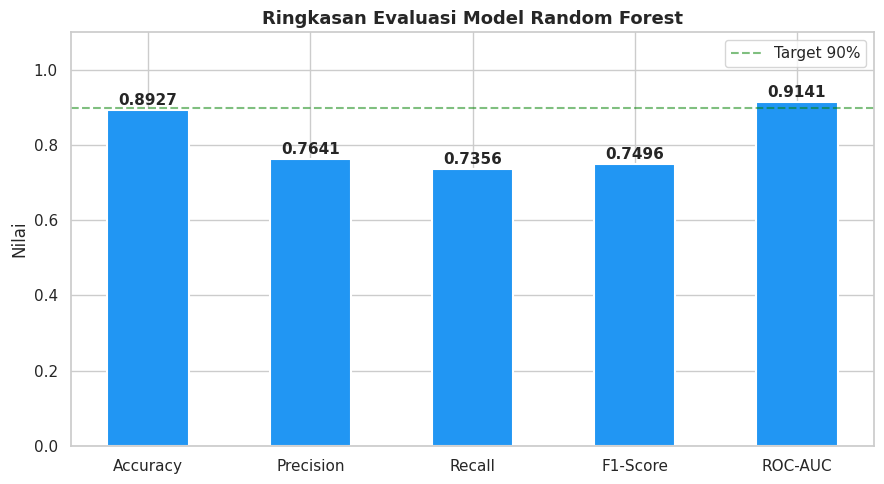

In [36]:
#Visualisasi Ringkasan Evaluasi
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values  = [acc, prec, rec, f1, auc]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics, values, color='#2196F3',
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Ringkasan Evaluasi Model Random Forest', fontsize=13, fontweight='bold')
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Target 90%')
ax.legend()

plt.tight_layout()
plt.savefig('evaluasi_ringkasan.png', bbox_inches='tight')
plt.show()

---
## 💾 FASE 7 — Simpan Model & Dataset Bersih

In [37]:
#Simpan Semua Artefak
joblib.dump(rf_model, 'random_forest.pkl')
joblib.dump(kmeans,   'kmeans.pkl')
joblib.dump(scaler,   'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

df_clean.to_csv('clean_credit_dataset.csv', index=False)
df_clustered.to_csv('clustered_credit_dataset.csv', index=False)

print(' Semua model dan dataset berhasil disimpan:')
print(' random_forest.pkl')
print(' kmeans.pkl')
print(' scaler.pkl')
print(' encoders.pkl')
print(' clean_credit_dataset.csv')
print(' clustered_credit_dataset.csv')

 Semua model dan dataset berhasil disimpan:
 random_forest.pkl
 kmeans.pkl
 scaler.pkl
 encoders.pkl
 clean_credit_dataset.csv
 clustered_credit_dataset.csv


In [38]:
#Download semua file dari Colab
from google.colab import files

files_to_download = [
    'random_forest.pkl', 'kmeans.pkl', 'scaler.pkl', 'encoders.pkl',
    'clean_credit_dataset.csv', 'clustered_credit_dataset.csv',
    'dist_loan_status.png', 'dist_numerik.png', 'dist_kategorikal.png',
    'heatmap_korelasi.png', 'smote_comparison.png', 'confusion_matrix.png',
    'roc_curve.png', 'feature_importance.png', 'elbow_method.png',
    'cluster_pca.png', 'cluster_profil.png', 'shap_summary.png',
    'shap_bar.png', 'shap_waterfall.png', 'evaluasi_ringkasan.png'
]

for f in files_to_download:
    try:
        files.download(f)
    except Exception as e:
        print(f'    {f}: {e}')

print('\n Download selesai!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download selesai!


---
## 📝 Kesimpulan

### Random Forest (Klasifikasi)
Model Random Forest berhasil memprediksi kelayakan kredit nasabah dengan performa yang baik. Fitur **loan_percent_income** (rasio pinjaman terhadap pendapatan) dan **loan_int_rate** (suku bunga) menjadi prediktor paling dominan berdasarkan feature importance dan SHAP values.

### K-Means (Clustering)
Segmentasi nasabah ke dalam 3 cluster menghasilkan kelompok yang dapat diinterpretasikan sebagai profil risiko rendah, sedang, dan tinggi. Silhouette Score mengindikasikan kualitas pemisahan cluster yang memadai.

### Explainable AI (SHAP)
SHAP berhasil menjelaskan prediksi model secara individual maupun global. Nasabah dengan rasio pinjaman/pendapatan tinggi dan suku bunga tinggi memiliki kontribusi SHAP positif terbesar terhadap prediksi gagal bayar, yang sejalan dengan pemahaman domain.

### Rekomendasi
- Lembaga kredit sebaiknya memperhatikan **rasio pinjaman terhadap pendapatan** sebagai indikator utama risiko.
- Nasabah dalam cluster risiko tinggi perlu mendapatkan evaluasi lebih ketat sebelum persetujuan kredit.
- Model ini dapat diintegrasikan ke sistem pengambilan keputusan kredit berbasis web.